In [ ]:
import warnings
from pathlib import Path

import prism

from imagematerials.concepts import knowledge_graph
from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.model import GenericMainModel, GenericMaterials, GenericStocks
from imagematerials.util import (
    export_to_netcdf, import_from_netcdf, rebroadcast_prep_data,
    read_climate_policy_config, read_circular_economy_config
)
from imagematerials.vehicles import (
    preprocess
)

import matplotlib.pyplot as plt


In [2]:
base_dir = "../data/raw"
climate_policy_scenario_dir = Path(base_dir) / 'SSP2'
prep_fp = Path("prep_vema.nc")

In [3]:
def prepare_scenario_data(scenario_name):
    scenario_path = Path(base_dir) / 'circular_economy_scenarios' / scenario_name
    circular_economy_scenario_dirs = {scenario_name: scenario_path}

    warnings.simplefilter("ignore")
    climate_policy_config = read_climate_policy_config(climate_policy_scenario_dir)
    circular_economy_config = read_circular_economy_config(circular_economy_scenario_dirs)

    prep_data = preprocess(base_dir, climate_policy_config, circular_economy_config)

    share_coords = set()
    for cur_type in prep_data["shares"].Type.values:
        share_coords.add(cur_type.split(" - ")[0])

    output_coords_type = [x for x in prep_data["stocks"].Type.values if x not in share_coords]
    output_coords_type += list(prep_data["shares"].coords["Type"].values)

    prep_data.pop("shares")

    new_prep_data = rebroadcast_prep_data(prep_data, knowledge_graph, dim="Type", output_coords=output_coords_type)
    new_prep_data = rebroadcast_prep_data(new_prep_data, knowledge_graph, dim="Region", output_coords=prep_data["stocks"].coords["Region"].values)
    new_prep_data["knowledge_graph"] = knowledge_graph
    new_prep_data["weights"] = new_prep_data.pop("vehicle_weights")

    return new_prep_data

In [4]:
scenario_names = ["base","slow"]
scenario_results = {}

for scenario in scenario_names:
    print(f"Preparing data for scenario: {scenario}")
    data = prepare_scenario_data(scenario)
    scenario_results[scenario] = data

Preparing data for scenario: base
Preparing data for scenario: slow
Missing mode: ('air_pas', 'mean')
Missing mode: ('air_freight', 'mean')
Missing mode: ('rail_reg', 'mean')
Missing mode: ('rail_hst', 'mean')
Missing mode: ('rail_freight', 'mean')
Missing mode: ('sea_shipping_small', 'mean')
Missing mode: ('sea_shipping_med', 'mean')
Missing mode: ('sea_shipping_large', 'mean')
Missing mode: ('sea_shipping_vl', 'mean')
Missing mode: ('LCV', 'mean')
Missing mode: ('MFT', 'mean')
Missing mode: ('HFT', 'mean')
Missing mode: ('midi_bus', 'mean')
Missing mode: ('reg_bus', 'mean')
Missing mode: ('inland_shipping', 'mean')
Missing mode: ('bicycle', 'mean')
Missing mode: ('car', 'mean')


Differences found in lifetime!


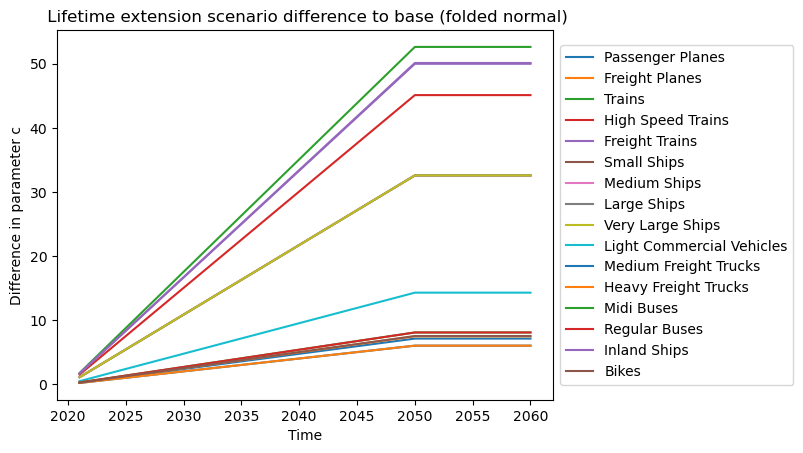

In [82]:
# Safe way to check for full equality
slow_lifetime = scenario_results["slow"]["lifetimes"]["folded_norm"]
base_lifetime = scenario_results["base"]["lifetimes"]["folded_norm"]
diff_mask = slow_lifetime != base_lifetime
differences = diff_mask.where(diff_mask, drop=True)
# Coordinates where differences occur
coords_where_diff = differences.coords

# Get differing values from each scenario
slow_diff_vals = slow_lifetime.where(diff_mask, drop=True)
base_diff_vals = base_lifetime.where(diff_mask, drop=True)

# Create a combined dataset for easy comparison
import xarray as xr

comparison = xr.Dataset({
    "slow": slow_diff_vals,
    "base": base_diff_vals
})
if diff_mask.any().item():
    print("Differences found in lifetime!")
comparison
 
diff_life = base_diff_vals - slow_diff_vals
diff_life = diff_life.sel(ScipyParam = "c").to_pandas()
ax = diff_life.plot.line()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel("Difference in parameter c")
ax.set_xlabel("Time")
plt.title(" Lifetime extension scenario difference to base (folded normal)")
plt.show()

In [78]:
diff_life

<xarray.DataArray (Time: 40, Type: 16, ScipyParam: 1)> Size: 5kB
array([[[ 0.23724792],
        [ 0.24911032],
        [ 1.75438596],
        [ 1.5037594 ],
        [ 1.66666667],
        [ 1.08604845],
        [ 1.08604845],
        [ 1.08604845],
        [ 1.08604845],
        [ 0.47619048],
        [ 0.20050125],
        [ 0.20050125],
        [ 0.26915114],
        [ 0.26915114],
        [ 1.67084378],
        [ 0.25062657]],

       [[ 0.47449585],
        [ 0.49822064],
        [ 3.50877193],
...
        [ 8.07453416],
        [50.12531327],
        [ 7.51879699]],

       [[ 7.11743772],
        [ 7.47330961],
        [52.63157895],
        [45.11278195],
        [50.        ],
        [32.58145365],
        [32.58145365],
        [32.58145365],
        [32.58145365],
        [14.28571429],
        [ 6.01503759],
        [ 6.01503759],
        [ 8.07453416],
        [ 8.07453416],
        [50.12531327],
        [ 7.51879699]]])
Coordinates:
  * Time        (Time) int64 320B 2021 2022 2023 2024 ... 2057 2058 2059 2060
  * Type        (Type) <U25 2kB 'Passenger Planes' 'Freight Planes' ... 'Bikes'
  * ScipyParam  (ScipyParam) <U5 20B 'c'

In [6]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [7]:
Region = list(scenario_results["base"]["stocks"].coords["Region"].values)
Time = [t for t in complete_timeline]
Cohort = Time
Type = list(scenario_results["base"]["stocks"].coords["Type"].values)
material = list(scenario_results["base"]["material_fractions"].coords["material"].values)

In [8]:
main_model_factory_base = ModelFactory(
    scenario_results["base"], complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

main_model_factory_slow = ModelFactory(
    scenario_results["slow"], complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

In [9]:
warnings.filterwarnings("ignore")
main_model_factory_base.simulate(simulation_timeline)
main_model_factory_slow.simulate(simulation_timeline)

In [69]:
production_base = main_model_factory_base.inflow_materials.to_array()
maintenance_base = main_model_factory_base.inflow_maintenance.to_array()
stock_base = main_model_factory_base.stock_by_cohort

production_slow = main_model_factory_slow.inflow_materials.to_array()
maintenance_slow = main_model_factory_slow.inflow_maintenance.to_array()
stock_slow = main_model_factory_slow.stock_by_cohort

target_types = [
    "Bikes", "Trucks", "Ships", "Trains", 
    "Cars", "High Speed Trains", "Airplanes"
]

production_base = knowledge_graph.rebroadcast_xarray(production_base, output_coords=target_types, dim="Type")
maintenance_base = knowledge_graph.rebroadcast_xarray(maintenance_base, output_coords=target_types, dim="Type")
production_slow = knowledge_graph.rebroadcast_xarray(production_slow, output_coords=target_types, dim="Type")
maintenance_slow = knowledge_graph.rebroadcast_xarray(maintenance_slow, output_coords=target_types, dim="Type")
stock_base = knowledge_graph.rebroadcast_xarray(stock_base, output_coords=target_types, dim="Type")
stock_slow = knowledge_graph.rebroadcast_xarray(stock_slow, output_coords=target_types, dim="Type")

In [70]:
production_base_aligned, production_slow_aligned = xr.align(production_base, production_slow, join="exact")
production_base_aligned = production_base_aligned.sel(material="Steel").sum(dim=["Region"])
production_slow_aligned = production_slow_aligned.sel(material="Steel").sum(dim=["Region"])

tolerance = 1e-12  # adjust as needed
prod_diff_mask = abs(production_base_aligned - production_slow_aligned) > tolerance


# Get differing values from each scenario
prod_slow_diff_vals = production_slow_aligned.where(prod_diff_mask, drop=True)
Prod_base_diff_vals = production_base_aligned.where(prod_diff_mask, drop=True)

prod_comparison = xr.Dataset({
    "slow": prod_slow_diff_vals,
    "base": Prod_base_diff_vals
})

if prod_diff_mask.any():
    print("Differences found!")
    prod_comparison
else:
    print("No meaningful differences found.")


Differences found!


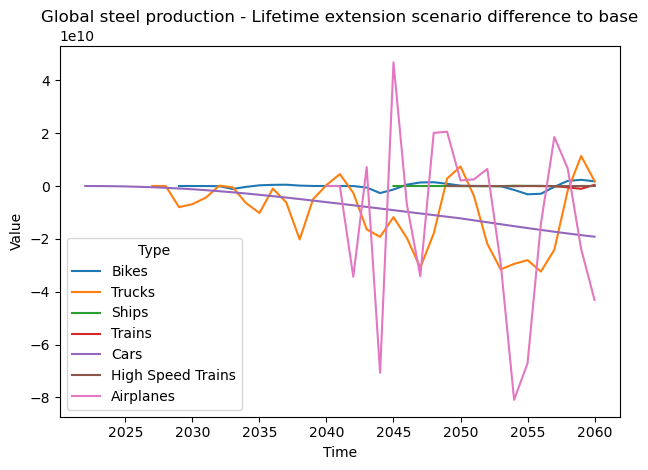

In [ ]:
difference = (Prod_base_diff_vals - prod_slow_diff_vals).to_pandas()

ax = difference.plot.line()
ax.set_ylabel("Value")
ax.set_xlabel("Time")
plt.title("Global steel production - Lifetime extension scenario difference to base")
plt.tight_layout()
plt.show()

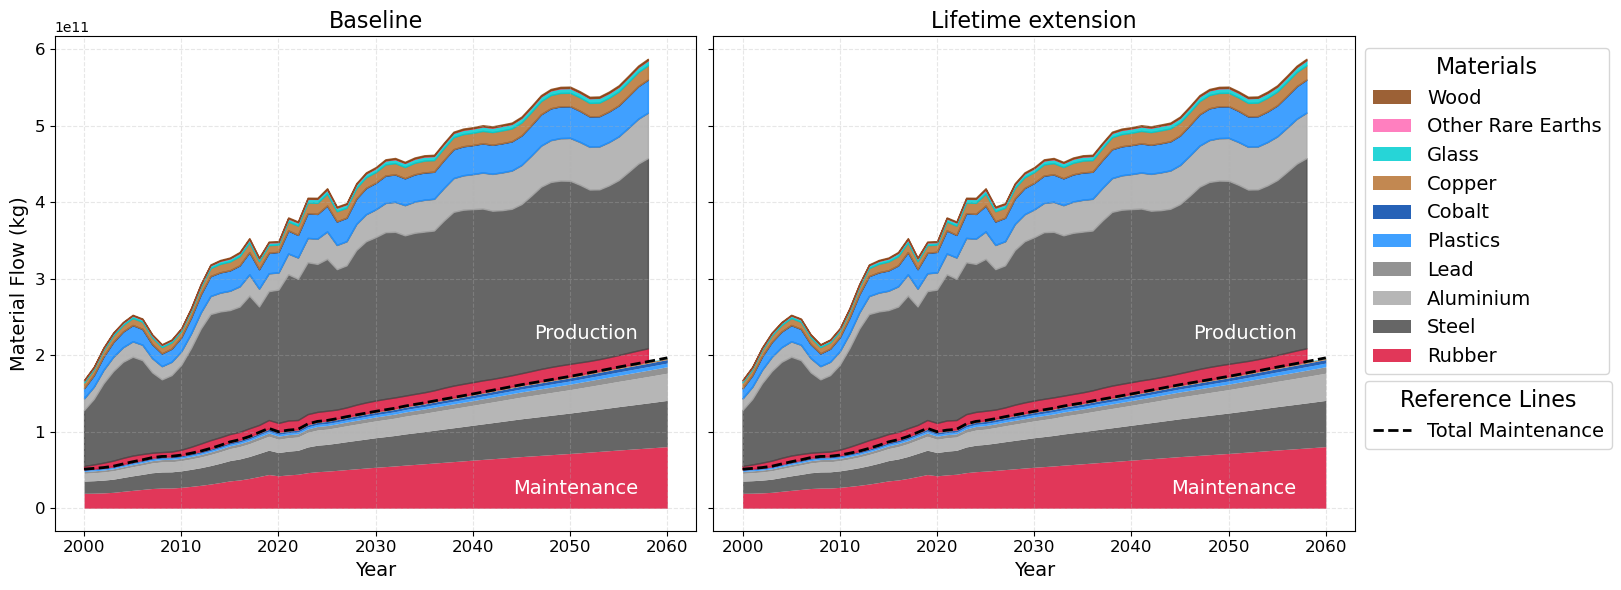

In [13]:
import matplotlib.pyplot as plt

# Define consistent colors
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

# Helper function to sort columns by total sum
def sort_columns_by_sum(df):
    return df.loc[:, df.sum(axis=0).sort_values(ascending=False).index]

# Helper function for a single train type plot
def plot_material_flow(ax, maint_df, prod_df, title):
    # Filter from 1972
    maint_df = maint_df[maint_df.index >= 2000]
    prod_df = prod_df[prod_df.index >= 2000]

    maint_df = sort_columns_by_sum(maint_df)
    prod_df = sort_columns_by_sum(prod_df)
    
    # Keep only non-zero materials across both
    valid_materials = (
        (maint_df != 0).any(axis=0) |
        (prod_df != 0).any(axis=0)
    )
    maint_df = maint_df.loc[:, valid_materials]
    prod_df = prod_df.loc[:, valid_materials]

    # Consistent material order and colors
    materials = maint_df.columns
    colors = [material_colors.get(mat, "#999999") for mat in materials]

    # Plot maintenance
    maint_df.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)
    ax.get_legend().remove()
    maintenance_total = maint_df.sum(axis=1)
    ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

    # Plot production stacked above maintenance
    prod_bottom = maintenance_total.copy()
    for mat in materials:
        top = prod_bottom + prod_df[mat]
        ax.fill_between(
            prod_df.index,
            prod_bottom,
            top,
            #label=f"Production: {mat}",
            color=material_colors.get(mat, "#999999"),
            alpha=0.85,
            #step="mid"
        )
        prod_bottom = top

    # Styling
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Year", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(visible=True, linestyle="--", alpha=0.3)

        # Add 'maintenance' label in bottom right (white)
    ax.text(
        maint_df.index[-1] - 3,                # rightmost year
        ax.get_ylim()[0] + 0.07 * ax.get_ylim()[1],  # just above bottom
        "Maintenance",
        color="white", fontsize=14, ha="right", va="bottom"
    )

    # Add 'maintenance' label just above the dashed line (black)
    ax.text(
        maint_df.index[-1] - 3,
        maintenance_total.iloc[-1] * 1.1,  # just above last value of line
        "Production",
        color="white", fontsize=14, ha="right", va="bottom"
    )


# === Load data ===
# Maintenance and production for both types
prod_df = production_base.sum(dim=["Region", "Type"]).to_pandas()

prod_df = prod_df.rolling(window=5, center=True).mean()

maint_df = maintenance_base.sum(dim=["Region", "Type"]).to_pandas()

rare_earths = ["Nd", "Mn", "Ni", "Ti","Li"]
maint_df["Other Rare Earths"] = maint_df[rare_earths].sum(axis=1)
prod_df["Other Rare Earths"] = prod_df[rare_earths].sum(axis=1)
maint_df = maint_df.drop(columns=rare_earths, errors="ignore")
prod_df = prod_df.drop(columns=rare_earths, errors="ignore")

rename_map = {
    "Pb": "Lead",
    "Co": "Cobalt",
    "Cu": "Copper"
}
maint_df = maint_df.rename(columns=rename_map)
prod_df = prod_df.rename(columns=rename_map)

# Lifetime extension
prod_df_extension = production_slow.sum(dim=["Region", "Type"]).to_pandas()

prod_df_extension = prod_df_extension.rolling(window=5, center=True).mean()

maint_df_extension = maintenance_slow.sum(dim=["Region", "Type"]).to_pandas()

rare_earths = ["Nd", "Mn", "Ni", "Ti","Li"]
maint_df_extension["Other Rare Earths"] = maint_df_extension[rare_earths].sum(axis=1)
prod_df_extension["Other Rare Earths"] = prod_df_extension[rare_earths].sum(axis=1)
maint_df_extension = maint_df_extension.drop(columns=rare_earths, errors="ignore")
prod_df_extension = prod_df_extension.drop(columns=rare_earths, errors="ignore")

rename_map = {
    "Pb": "Lead",
    "Co": "Cobalt",
    "Cu": "Copper"
}
maint_df_extension = maint_df_extension.rename(columns=rename_map)
prod_df_extension = prod_df_extension.rename(columns=rename_map)

# === Create side-by-side plot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_material_flow(axes[0], maint_df, prod_df, "Baseline")
plot_material_flow(axes[1], maint_df_extension, prod_df_extension, "Lifetime extension")

# Shared Y label
axes[0].set_ylabel("Material Flow (kg)", fontsize=14)

# Get all handles
all_handles, all_labels = axes[1].get_legend_handles_labels()

# Separate Total Maintenance
material_handles_labels = [(h, l) for h, l in zip(all_handles, all_labels) if not l.startswith("Total")]
maintenance_handles_labels = [(h, l) for h, l in zip(all_handles, all_labels) if l.startswith("Total")]

# Shared legend (outside)
handles, labels = axes[1].get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]
material_handles_labels = list(zip(*material_handles_labels))
fig.legend(material_handles_labels[0][::-1], material_handles_labels[1][::-1],
           title="Materials", bbox_to_anchor=(0.85, 0.64), loc="center left", fontsize=14, title_fontsize=16)

# Total line legend
if maintenance_handles_labels:
    mh, ml = zip(*maintenance_handles_labels)
    fig.legend(mh, ml, title="Reference Lines", bbox_to_anchor=(0.85, 0.3), loc="center left", fontsize=14, title_fontsize=16)

# Layout optimization for slides
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()


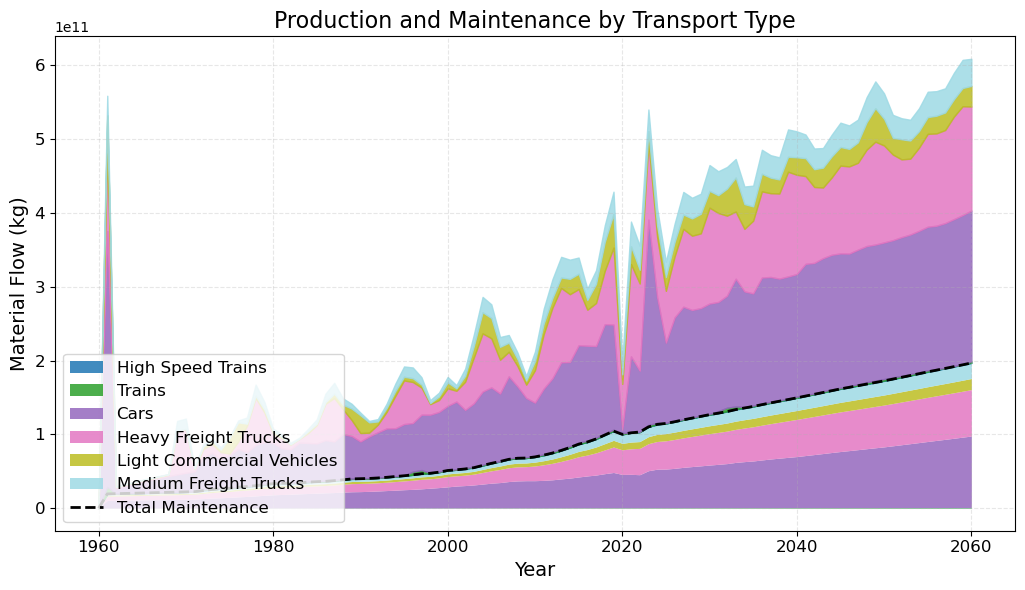

In [14]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === Load data ===

prod_by_type = production_base.sum(dim=["Region", "material"]).to_pandas()
maint_by_type = maintenance_base.sum(dim=["Region", "material"]).to_pandas()


type_cmap = cm.get_cmap('tab20', len(target_types))  # Choose a colormap with enough unique colors
type_colors = {t: mcolors.to_hex(type_cmap(i)) for i, t in enumerate(target_types)}
colors = [type_colors[t] for t in target_types]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))

# Plot maintenance (bottom layer)
maint_by_type.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)

# Plot total maintenance as dashed black line
maintenance_total = maint_by_type.sum(axis=1)
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

# Plot production stacked above maintenance
prod_bottom = maintenance_total.copy()
for t in target_types:
    top = prod_bottom + prod_by_type[t]
    ax.fill_between(
        prod_by_type.index,
        prod_bottom,
        top,
        color=type_colors.get(t, "#999999"),
        alpha=0.85
    )
    prod_bottom = top

# Styling
ax.set_title("Production and Maintenance by Transport Type", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Material Flow (kg)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Create legend for types (materials not shown)
from matplotlib.patches import Patch
type_patches = [Patch(color=type_colors[t], label=t) for t in target_types]
legend1 = ax.legend(handles=type_patches, title="Transport Types", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add Total Maintenance to legend
ax.legend(loc="lower left", fontsize=12)
ax.add_artist(legend1)  # Add the first legend manually

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()

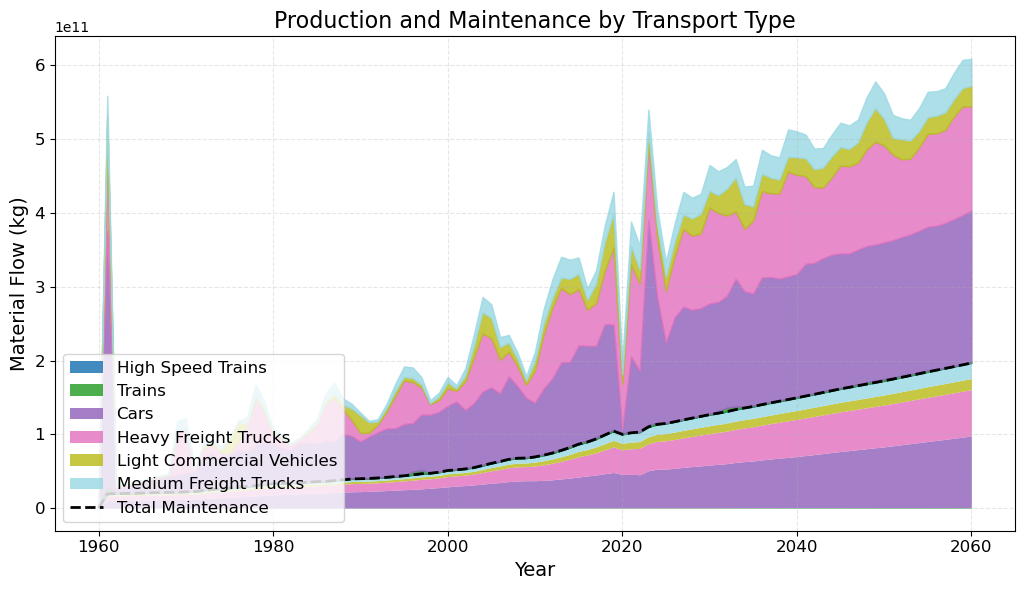

In [15]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === Load data ===

prod_by_type = production_slow.sum(dim=["Region", "material"]).to_pandas()
maint_by_type = maintenance_slow.sum(dim=["Region", "material"]).to_pandas()


type_cmap = cm.get_cmap('tab20', len(target_types))  # Choose a colormap with enough unique colors
type_colors = {t: mcolors.to_hex(type_cmap(i)) for i, t in enumerate(target_types)}
colors = [type_colors[t] for t in target_types]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))

# Plot maintenance (bottom layer)
maint_by_type.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)

# Plot total maintenance as dashed black line
maintenance_total = maint_by_type.sum(axis=1)
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

# Plot production stacked above maintenance
prod_bottom = maintenance_total.copy()
for t in target_types:
    top = prod_bottom + prod_by_type[t]
    ax.fill_between(
        prod_by_type.index,
        prod_bottom,
        top,
        color=type_colors.get(t, "#999999"),
        alpha=0.85
    )
    prod_bottom = top

# Styling
ax.set_title("Production and Maintenance by Transport Type", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Material Flow (kg)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Create legend for types (materials not shown)
from matplotlib.patches import Patch
type_patches = [Patch(color=type_colors[t], label=t) for t in target_types]
legend1 = ax.legend(handles=type_patches, title="Transport Types", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add Total Maintenance to legend
ax.legend(loc="lower left", fontsize=12)
ax.add_artist(legend1)  # Add the first legend manually

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()